# Initial Imports and Constants

In [636]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import math

In [637]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [638]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [639]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [640]:
TOI_id = 'TOI 1339'
search_result = lk.search_lightcurve(TOI_id, author='SPOC', exptime=20)
print(search_result)


SearchResult containing 19 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 41 2021   SPOC      20   269701147      0.0
  1 TESS Sector 48 2022   SPOC      20   269701147      0.0
  2 TESS Sector 49 2022   SPOC      20   269701147      0.0
  3 TESS Sector 51 2022   SPOC      20   269701147      0.0
  4 TESS Sector 52 2022   SPOC      20   269701147      0.0
  5 TESS Sector 55 2022   SPOC      20   269701147      0.0
  6 TESS Sector 56 2022   SPOC      20   269701147      0.0
  7 TESS Sector 59 2022   SPOC      20   269701147      0.0
  8 TESS Sector 60 2022   SPOC      20   269701147      0.0
  9 TESS Sector 73 2023   SPOC      20   269701147      0.0
 10 TESS Sector 75 2024   SPOC      20   269701147      0.0
 11 TESS Sector 76 2024   SPOC      20   269701147      0.0
 12 TESS Sector 77 2024   SPOC      20   269701147      0

In [641]:
lc_collection = search_result.download_all()
# lc_collection.plot()
# plt.show()
print(lc_collection)

LightCurveCollection of 19 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=48 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=49 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=51 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=52 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=55 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=56 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=59 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=60 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=73 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

In [642]:
### mask transits out before normalizing and removing outliers 
if mask_transits == True:
    ### mask transit times before flattening
    transit_times1 = [2425.781568953845, 2434.662341014224, 2443.542433854565, 2612.269605555201, 
                      2621.150711744474, 2630.028309381482, 2647.7901560860028, 2656.6689299046443, 
                      2701.0726436001796, 2718.8325586278097, 2727.711138989694, 2736.592174304549, 
                      2798.754439848722, 2807.635765630848, 2816.514784693573, 2825.3959659944494, 
                      2834.2775118096188, 2843.157001749279, 2852.037474535383, 2914.1982558647287, 
                      2923.0774462294557, 2931.95742730768, 2940.8414324739406, 2958.6010750609407, 
                      3296.051557068873, 3340.4546698842287, 3349.334584426969, 3358.213179889953, 
                      3367.09871266578, 3375.975012499317, 3384.855477625585, 3393.7383879034232, 
                      3420.375784008054, 3438.1370786259045, 3447.0195015529102, 3455.8984858914405, 
                      3464.779269028733, 3473.6616442738245, 3535.8224418879954, 3544.700577259685, 
                      3553.58245247158, 3562.463204754517, 3571.3445852104765, 3580.222381562287, 
                      3615.7448587847834, 3633.5066307830684, 3660.145225315547]
    transit_times2 = [2440.5451041395636, 2612.024066774251, 2640.608217075082, 2697.771532046253, 
                      2726.3529519997155, 2812.0969582335897, 2840.672570509771, 2926.4192502191313, 
                      3297.9702906592634, 3355.1300273809297, 3383.7110932454984, 3440.876311566781, 
                      3555.1949950938742, 3583.7722975217457, 3612.349943590013, 3640.930674916817]
    transit_times3 = [2433.9178071047745, 2664.0249803207125, 2702.35279639, 2740.717881361123, 
                      2817.4092025217515, 2932.4626746983276, 3354.303842596172, 3392.660945743557, 
                      3546.0736173384444, 3622.7701205436197, 3661.1279483174494]
    T14_1= 2.939 * 0.0416667 
    T14_2= 4.162 * 0.0416667 
    T14_3= 5.36 * 0.0416667
    
    masked_lc = lc_collection.stitch()

    times = masked_lc.time.value

    ### Initialize a mask with all False values (i.e., include all data points initially)
    mask = np.zeros_like(times, dtype=bool)

    ### Iterate through each transit time and update the mask
    for transit_time in transit_times1:
        mask |= (times > (transit_time - T14_1/2)) & (times < (transit_time + T14_1/2))

    for transit_time in transit_times2:
        mask |= (times > (transit_time - T14_2/2)) & (times < (transit_time + T14_2/2))

    for transit_time in transit_times3:
        mask |= (times > (transit_time - T14_3/2)) & (times < (transit_time + T14_3/2))

    ### Flatten the masked light curve
    masked_lc = masked_lc.flatten(window_length=2901, mask=mask).remove_outliers()
    combined_lc = masked_lc
else:
    ### flatten unmasked lightcurve 
    combined_lc = lc_collection.stitch().flatten(window_length=1901).remove_outliers()

# combined_lc.plot()
# plt.show()

In [643]:
# clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [644]:
# # Normalize, flatten, and remove outliers
# processed_lcs = [
#     lc.normalize().flatten(window_length=2101).remove_outliers(sigma=5)
#     for lc in clean_lcs
# ]

In [645]:
# # Stitch into one combined light curve
# combined_lc = processed_lcs[0]
# for lc in processed_lcs[1:]:
#     combined_lc = combined_lc.append(lc)



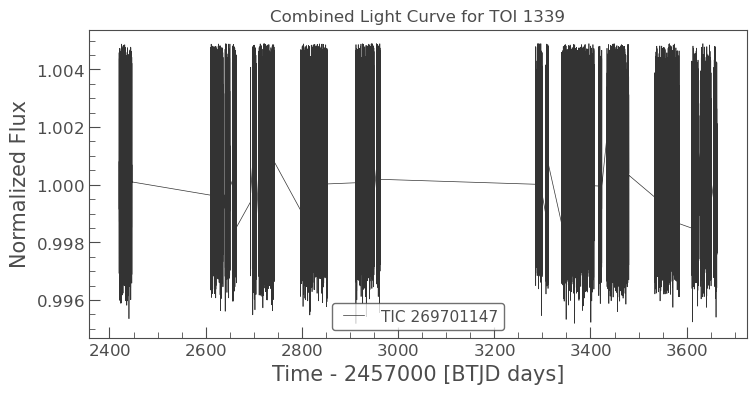

In [646]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [647]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[2419.98945919 2419.98969068 2419.98992216 ... 3662.82669654 3662.82692802
 3662.8271595 ]
[0.99915622 1.00098336 1.0008979  ... 1.00111907 0.99795771 1.00078277]


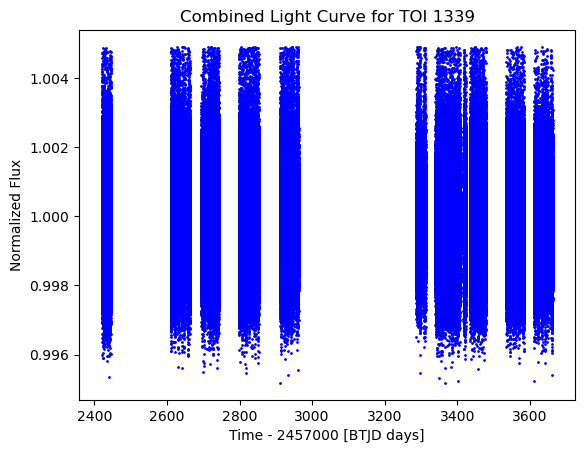

In [648]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

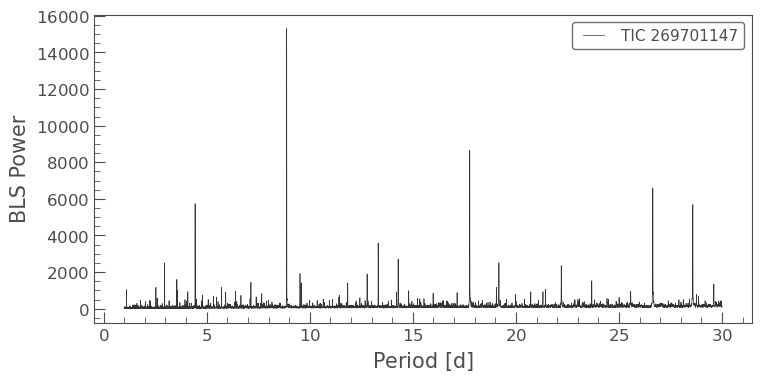

In [649]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1, 30, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [650]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")
print(f"Best candidate dur: {planet_1_dur.value:.5f} days")

Best candidate period: 8.88009 days
Best candidate t0: 2425.79946 days
Best candidate dur: 0.10000 days


In [651]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*2.5)

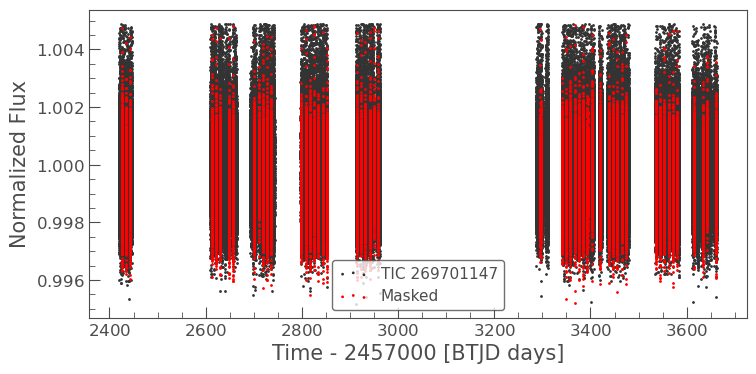

In [652]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [653]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


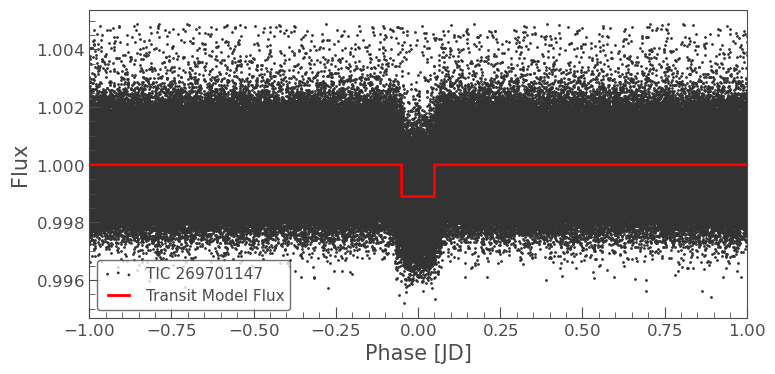

In [654]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

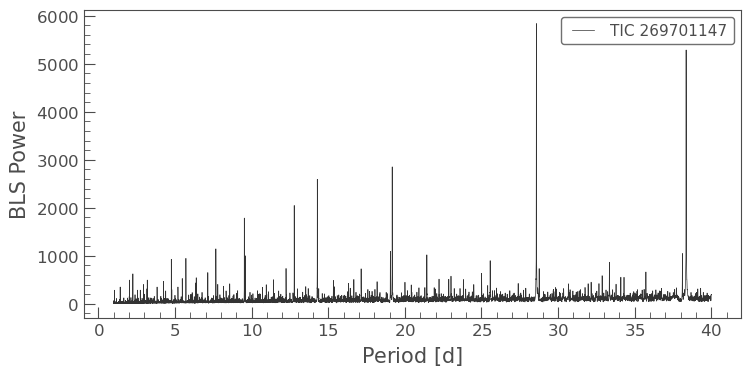

In [655]:
period = np.linspace(1, 40, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [656]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 28.57966 days
Best candidate t0 2: 2440.56946 days


In [657]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [658]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*2.5)

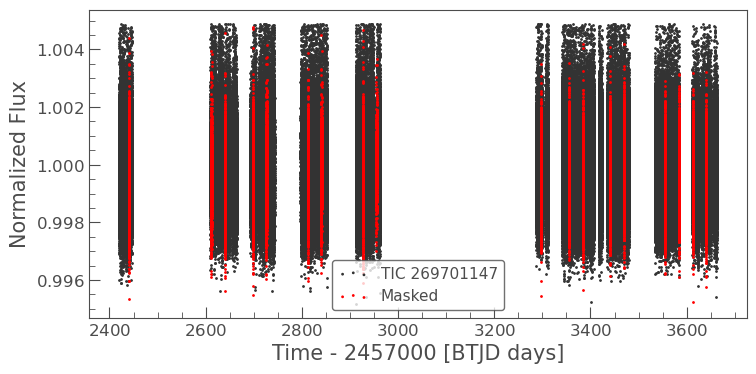

In [659]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [660]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

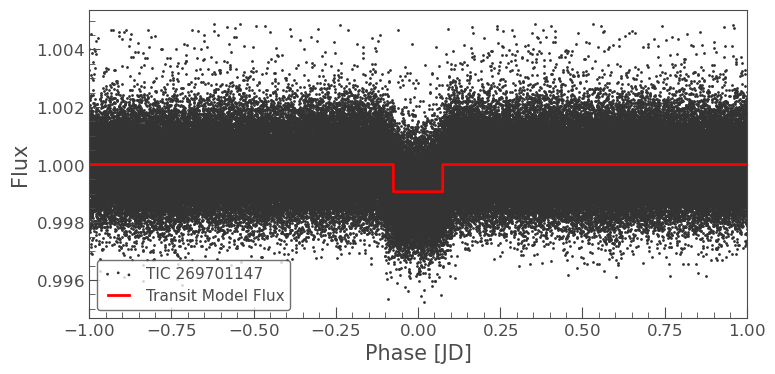

In [661]:
ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 3

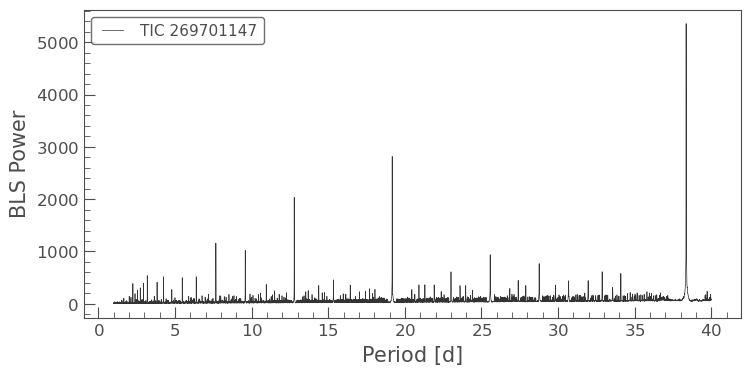

In [662]:
period = np.linspace(1, 40, 10000)
bls_3 = masked_lc_2.to_periodogram('bls', period=period, frequency_factor=500)
bls_3.plot()
plt.show()

In [663]:
planet_3_period = bls_3.period_at_max_power
planet_3_t0 = bls_3.transit_time_at_max_power
planet_3_dur = bls_3.duration_at_max_power

print(f"Best candidate period 3: {planet_3_period.value:.5f} days")
print(f"Best candidate t0 3: {planet_3_t0.value:.5f} days")

Best candidate period 3: 38.35014 days
Best candidate t0 3: 2433.90946 days


In [664]:
planet_3_mask = bls_3.get_transit_mask(period=planet_3_period,
                                     transit_time=planet_3_t0,
                                     duration=planet_3_dur*2.5)

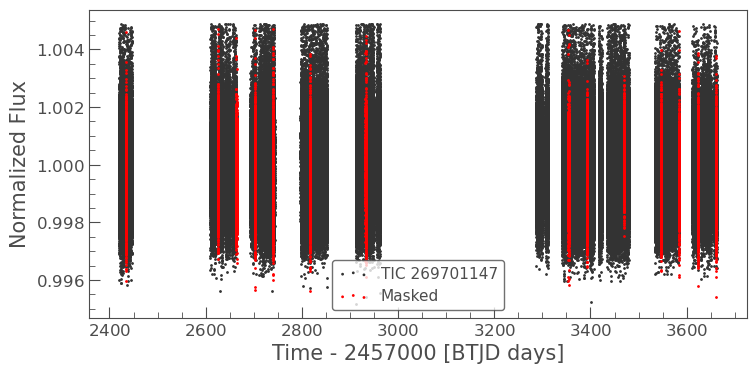

In [665]:
masked_lc_3 = masked_lc_2[~planet_3_mask]
ax = masked_lc_3.scatter();
masked_lc_2[planet_3_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [666]:
planet_3_model = bls_3.get_transit_model(period=planet_3_period,
                                       transit_time=planet_3_t0,
                                       duration=planet_3_dur)

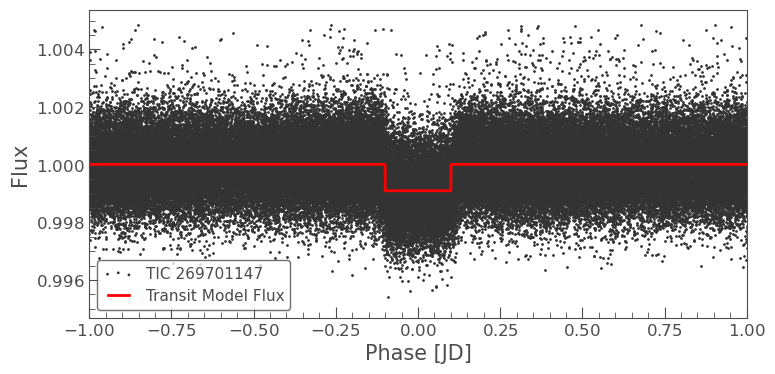

In [667]:
ax = masked_lc_2.fold(planet_3_period, planet_3_t0).scatter()
planet_3_model.fold(planet_3_period, planet_3_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## transit models 

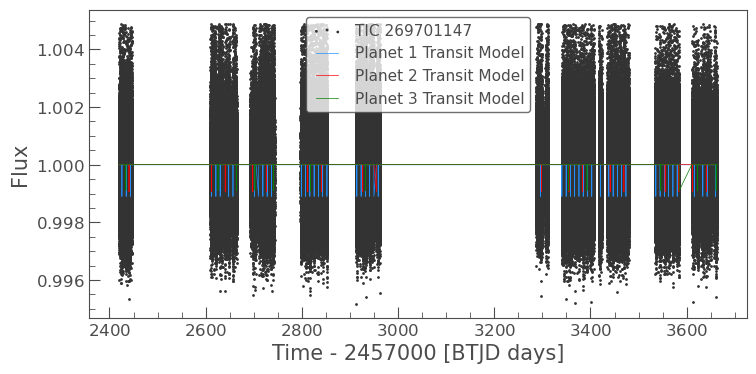

In [668]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');
# planet_4_model.plot(ax=ax, c='purple', label='Planet 4 Transit Model');
# planet_5_model.plot(ax=ax, c='orange', label='Planet 5? Transit Model');
# planet_6_model.plot(ax=ax, c='pink', label='Planet 6 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

## find transit times based on models

In [669]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = np.sort(planet_1_model.time.value[peaks_1])
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[2425.79952233 2434.67932051 2443.55956348 2612.28129436 2621.16122226
 2630.04138705 2647.80156542 2656.68157172 2701.08205093 2710.0029687
 2718.84219745 2727.72241902 2736.60242622 2798.76338421 2807.64317096
 2816.52316391 2825.40337132 2834.28332387 2843.16348115 2852.04362027
 2914.20422433 2923.0843886  2931.96429458 2940.84419355 2949.72131821
 2958.60468076 3296.04795137 3340.44836775 3349.32851377 3358.20867538
 3367.088638   3375.96883965 3384.84884182 3393.72887839 3402.60892919
 3420.3691482  3438.12970041 3447.00942688 3455.88964371 3464.76965733
 3473.64966978 3535.81039234 3544.69040041 3553.57060728 3562.45056293
 3571.33073802 3580.21087004 3615.73114088 3633.49134673 3642.37523155
 3660.1316096 ]


In [670]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = np.sort(planet_2_model.time.value[peaks_2])
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[2440.56923447 2612.04727136 2640.62687957 2697.78619044 2726.36591489
 2812.10481394 2840.68453246 2926.42343578 2955.05938629 3297.95902532
 3355.11845547 3383.69815953 3440.85726955 3469.4370931  3555.17595306
 3583.75579557 3612.33534153 3640.9150719 ]


In [671]:
# Find all local minima (i.e., transit dips)
peaks_3, _ = find_peaks(-planet_3_model.flux.value, prominence=1e-5)
transit_times_3 = np.sort(planet_3_model.time.value[peaks_3])
fluxes_3 = planet_3_model.flux.value[peaks_3]

print("Planet 3 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_3)

Planet 3 transit dip times and depths:
[2433.90940077 2625.65997912 2664.01046579 2702.3603039  2740.71037385
 2817.4106769  2932.46081243 3354.31268478 3392.66267873 3546.0633383
 3584.34514971 3622.76348474 3661.11376746]


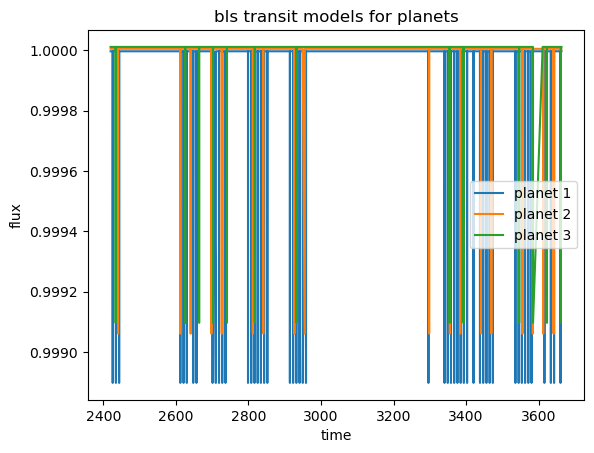

In [672]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')
# plt.plot(planet_4_model.time.value, planet_4_model.flux.value, label='planet 4')
# plt.plot(planet_5_model.time.value, planet_5_model.flux.value, label='planet 5?')
# plt.plot(planet_6_model.time.value, planet_6_model.flux.value, label='planet 6?')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1700,1800)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [673]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [674]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [675]:

def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        # ### fit parabola to the chisq
        # p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        # ### Extract the coefficients   y = ax^2 + bx + c
        # a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        # ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        # tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        # ### Calculate the minimum chi-squared value
        # chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        # tc_chi_parabola[j] = tc_best_fit
    
        # ### Calculate the parabola best fit 
        # p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        # ### calculate ttv from parabola fit 
        # ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        # err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # Find the intersection using root_scalar
        intersections = []
        for k in range(len(tc1) - 1):
            if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
                sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
                if sol.converged:
                    intersections.append((sol.root - min_chi_time))
        errors.append(intersections)

        # errors = np.array(errors)

        # ### avg the errors
        # sig = np.sqrt(errors[0]**2 + errors[1]**2)
        # err_tc_chi.append(sig)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv, errors

In [676]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [677]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [678]:
### stellar params
q1 = 0.304
q2 = 0.40

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

0.44108956006688715
0.11027239001672175


## Planet 1

In [679]:
### Planet params 
# planet b
per_1=  8.8803232 #8.8803256
rp_1= 0.0333265970068500 #0.03319
b_1=  0.522936735232103 #0.610
T14_1= 3.06623299086887 * 0.0416667  #2.939 * 0.0416667  # convert to days from hours 


In [680]:
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [681]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []
err_tc_chi = []

In [682]:
tc_chi_1, ttv_1, tc_err1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [683]:
print(tc_chi_1)
# print(tc_err1)
# print(len(tc_chi_1))
# print(len(tc_err1))

[2425.78167114 2434.66247032 2443.54237961 2612.26844817 2621.15104541
 2630.02753986 2647.7900539  2656.66972653 2701.07254142 2709.93306541
 2718.83235426 2727.7109075  2736.59224936 2798.75454203 2807.63566345
 2816.51465539 2825.39553014 2834.27748469 2843.15697464 2852.03844842
 2914.19738415 2923.07788209 2931.95712074 2940.83968904 2949.83192891
 2958.60151092 3296.05112121 3340.45320593 3349.33435295 3358.21284622
 3367.10014952 3375.97534617 3384.85501467 3393.7383879  3402.44226239
 3420.37698938 3438.13654059 3447.01927007 3455.89881956 3464.77916685
 3473.6621823  3535.82157019 3544.70057726 3553.5821188  3562.46374279
 3571.34425154 3580.22238156 3615.74532174 3633.50652859 3642.20856475
 3660.14478946]


In [684]:
### after inspection of single transits
values_to_remove_1 = [2709.9330654109963, 2949.8320311053144, 3402.4429568302817, 3642.2085647518275]
# Define a tolerance level (adjust if needed)
tolerance = 1e-1

# tc_chi_1 = [x for x in tc_chi_1 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_1)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_1_cleaned = []
ttv_1_cleaned = []
tc_err_1_cleaned = []

for i in range(len(tc_chi_1)):
    if not any(math.isclose(tc_chi_1[i], val, abs_tol=tolerance) for val in values_to_remove_1):
        tc_chi_1_cleaned.append(tc_chi_1[i])
        ttv_1_cleaned.append(ttv_1[i])
        tc_err_1_cleaned.append(tc_err1[i])

# Overwrite the originals if needed
tc_chi_1 = tc_chi_1_cleaned
ttv_1 = ttv_1_cleaned
tc_err1 = tc_err_1_cleaned
print("Modified List (after removal):", tc_chi_1)
# print(tc_err1)


Modified List (after removal): [2425.781671135145, 2434.6624703174352, 2443.5423796109203, 2612.2684481713577, 2621.1510454117415, 2630.0275398575673, 2647.7900538979006, 2656.669726531292, 2701.0725414166154, 2718.8323542612056, 2727.710907504246, 2736.5922493638554, 2798.7545420305955, 2807.6356634491485, 2816.514655391101, 2825.395530143617, 2834.277484692579, 2843.156974635499, 2852.0384484248025, 2914.197384150204, 2923.0778820870382, 2931.9571207364143, 2940.839689041113, 2958.6015109188284, 3296.051121211378, 3340.4532059302223, 3349.3343529494396, 3358.2128462226856, 3367.10014952418, 3375.9753461665846, 3384.8550146672706, 3393.7383879034232, 3420.3769893786307, 3438.136540591031, 3447.0192700680527, 3455.8988195587076, 3464.7791668472623, 3473.662182303581, 3535.821570188835, 3544.700577259685, 3553.582118804313, 3562.4637427893786, 3571.3442515432093, 3580.222381562287, 3615.7453217433413, 3633.5065285943206, 3660.1447894582507]


In [685]:
# tc_err_1 = []
# for i in range(len(tc_err1)):
#     sig = np.sqrt(tc_err1[i][0]**2 + tc_err1[i][1]**2)
#     tc_err_1.append(sig)

tc_err_1 = []
for i in range(len(tc_err1)):
    if len(tc_err1[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err1[i][0]**2 + tc_err1[i][1]**2)
        tc_err_1.append(sig)
    else:
        print(f"Unexpected format in tc_err1[{i}]: {tc_err1[i]}, {tc_chi_1[i]}")

# print(tc_err_1)

In [686]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi_1

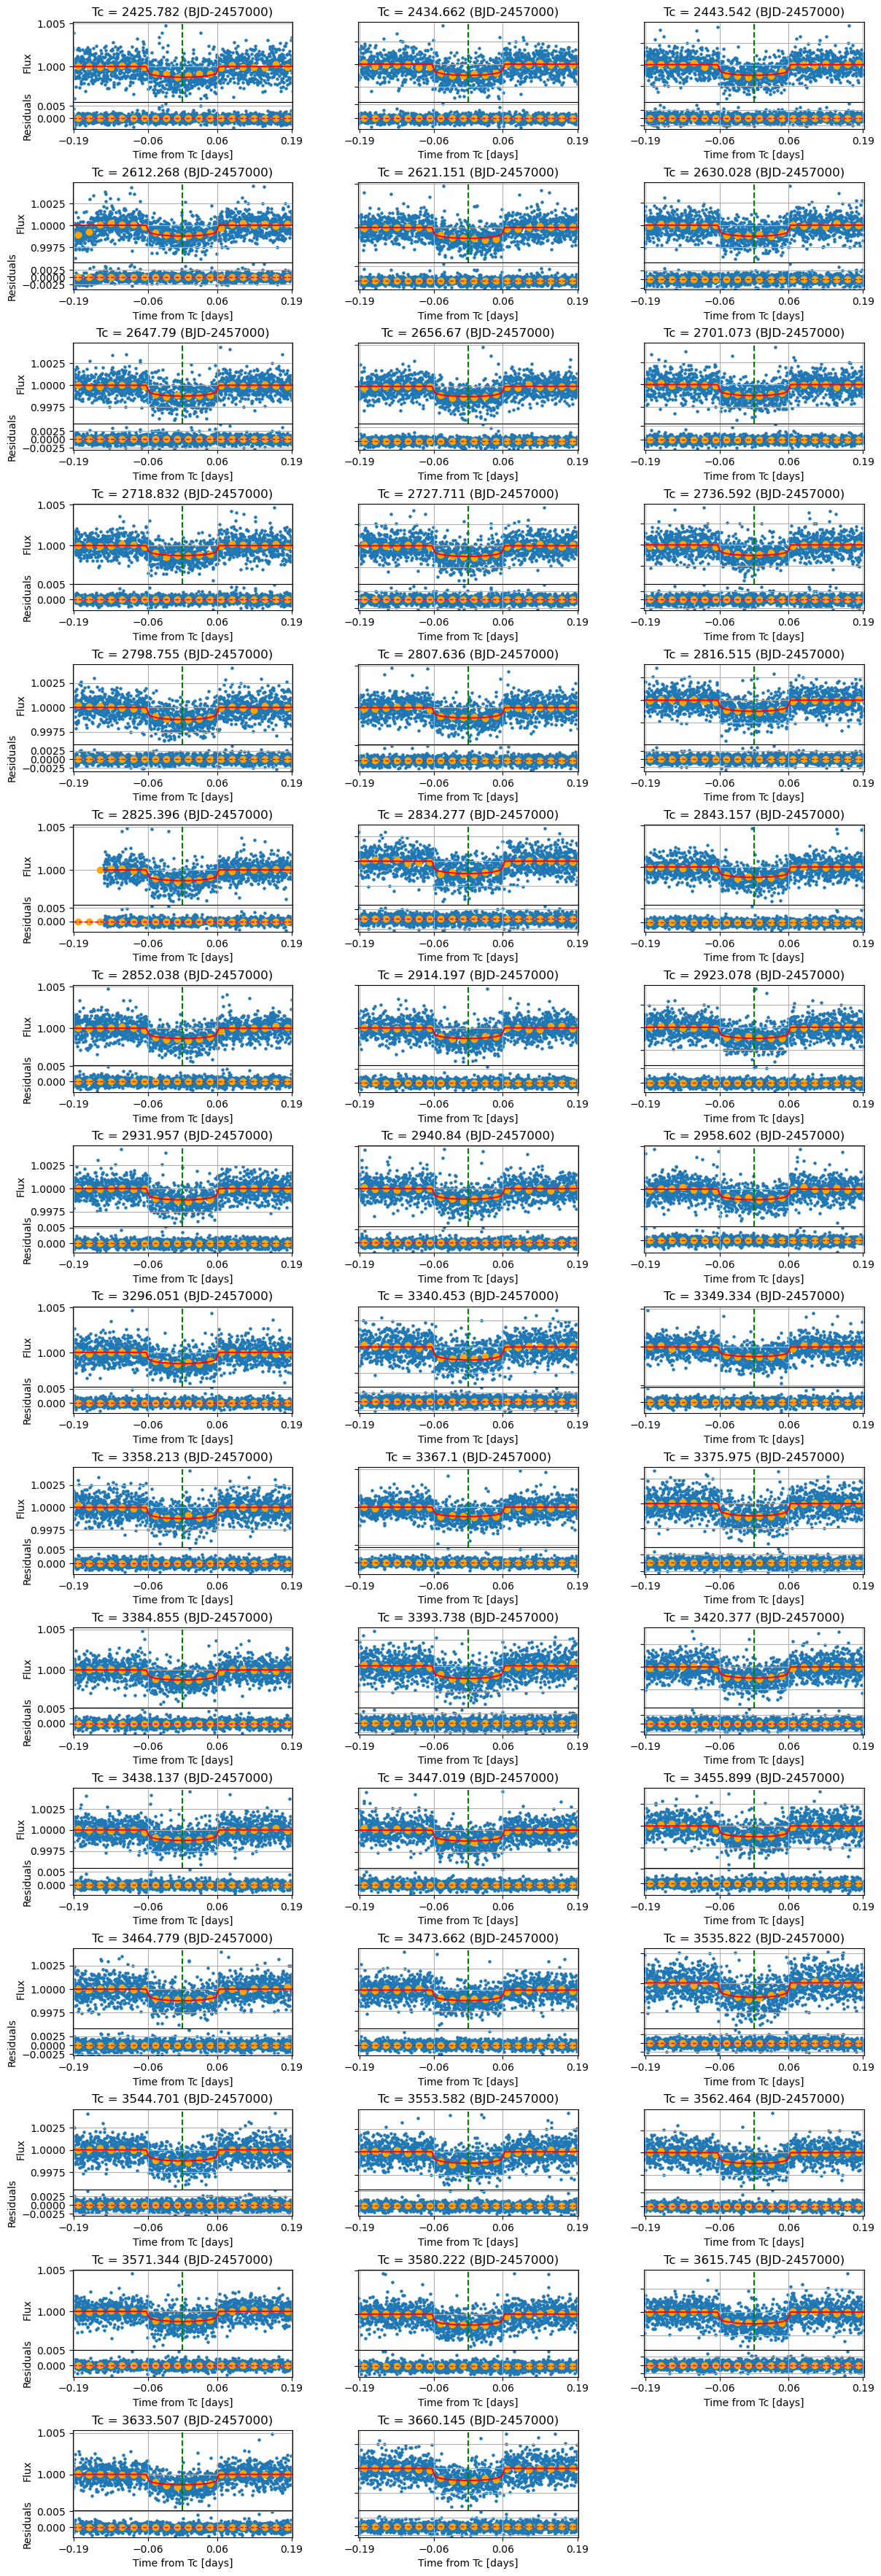

In [687]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

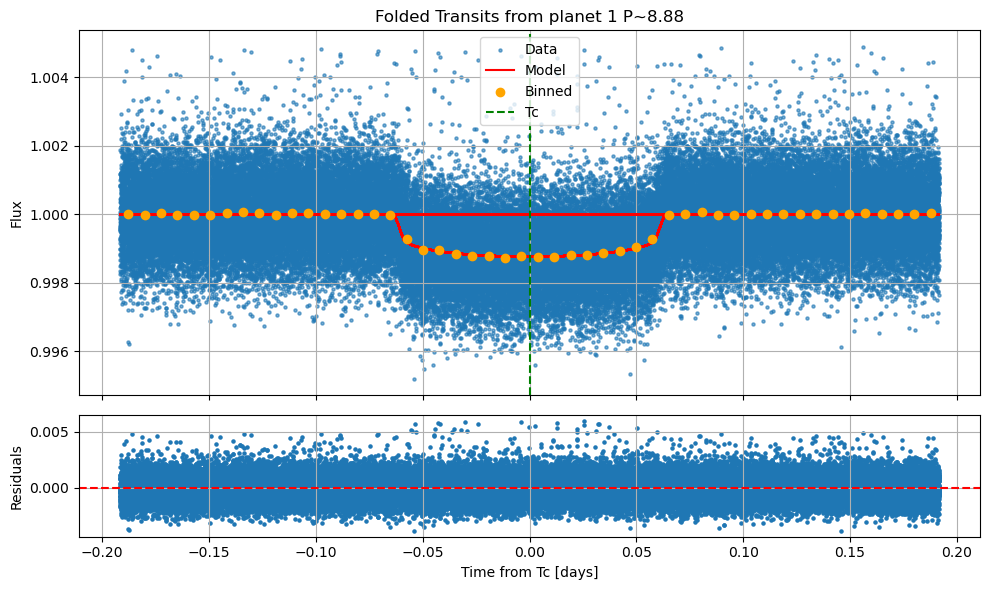

In [688]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 1 P~{round(planet_1_period.value, 3)}')

## Planet 2

In [689]:
### Planet params (from barros et al 2022)
# planet b
per_2=  28.579889 #28.579743
rp_2= 0.0312382795966642 #0.03118
b_2=  0.482378819760311 #0.630
T14_2= 4.47016349523855 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 


In [690]:
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [691]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []
err_tc_chi = []

In [692]:
tc_chi_2, ttv_2, tc_err2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [693]:
print(tc_chi_2)

[2440.54537726 2612.02574982 2640.60736004 2697.77200958 2726.35273503
 2812.0976401  2840.67268727 2926.41826393 2954.97546897 3297.97020318
 3355.13063433 3383.71100572 3440.87612175 3469.41657256 3555.19480526
 3583.76764076 3612.34985606 3640.93325676]


In [694]:
### after inspection of single transits
values_to_remove_2 = [2954.949653497008, 3469.45023132]
# Define a tolerance level (adjust if needed)
tolerance = 1e-1

# tc_chi_2 = [x for x in tc_chi_2 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_2)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_2_cleaned = []
ttv_2_cleaned = []
tc_err_2_cleaned = []

for i in range(len(tc_chi_2)):
    if not any(math.isclose(tc_chi_2[i], val, abs_tol=tolerance) for val in values_to_remove_2):
        tc_chi_2_cleaned.append(tc_chi_2[i])
        ttv_2_cleaned.append(ttv_2[i])
        tc_err_2_cleaned.append(tc_err2[i])

# Overwrite the originals if needed
tc_chi_2 = tc_chi_2_cleaned
ttv_2 = ttv_2_cleaned
tc_err2 = tc_err_2_cleaned
print("Modified List (after removal):", tc_chi_2)


Modified List (after removal): [2440.5453772579517, 2612.0257498217884, 2640.607360037848, 2697.772009576271, 2726.3527350293425, 2812.097640098747, 2840.6726872691265, 2926.4182639328533, 3297.970203178181, 3355.1306343302267, 3383.7110057186396, 3440.8761217520487, 3555.194805258147, 3583.7676407579665, 3612.3498560606936, 3640.9332567617016]


In [695]:
# tc_err_2 = []
# for i in range(len(tc_err2)):
#     sig = np.sqrt(tc_err2[i][0]**2 + tc_err2[i][1]**2)
#     tc_err_2.append(sig)

tc_err_2 = []
for i in range(len(tc_err2)):
    if len(tc_err2[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err2[i][0]**2 + tc_err2[i][1]**2)
        tc_err_2.append(sig)
    else:
        print(f"Unexpected format in tc_err2[{i}]: {tc_err2[i]}, {tc_chi_2[i]}")

print(tc_err_2)

[0.001604363074117625, 0.0025063700685299464, 0.0014843066794477508, 0.0014259077458965276, 0.001806786980737914, 0.001791063343811331, 0.001286470029733751, 0.0015412322496900414, 0.0018503798796286046, 0.001013499109876804, 0.0013870070784908707, 0.001658212059346232, 0.0015182858855263806, 0.0019316873500147085, 0.0014439499292866202, 0.002070763593795179]


In [696]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi_2

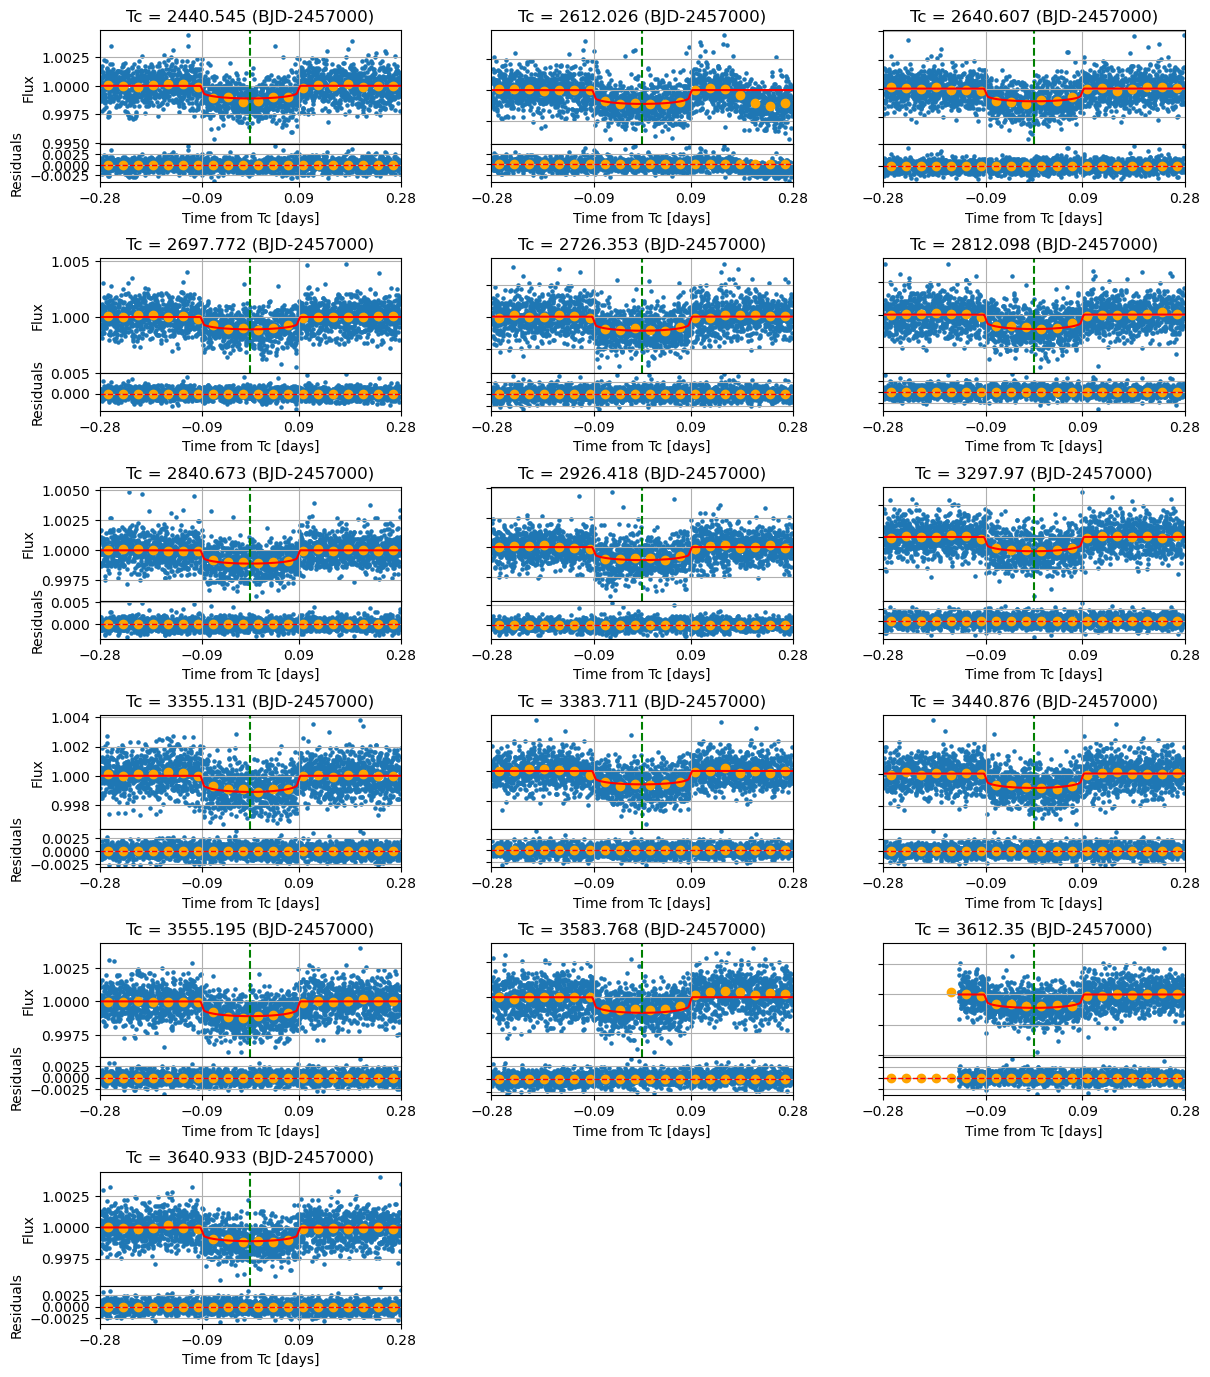

In [697]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

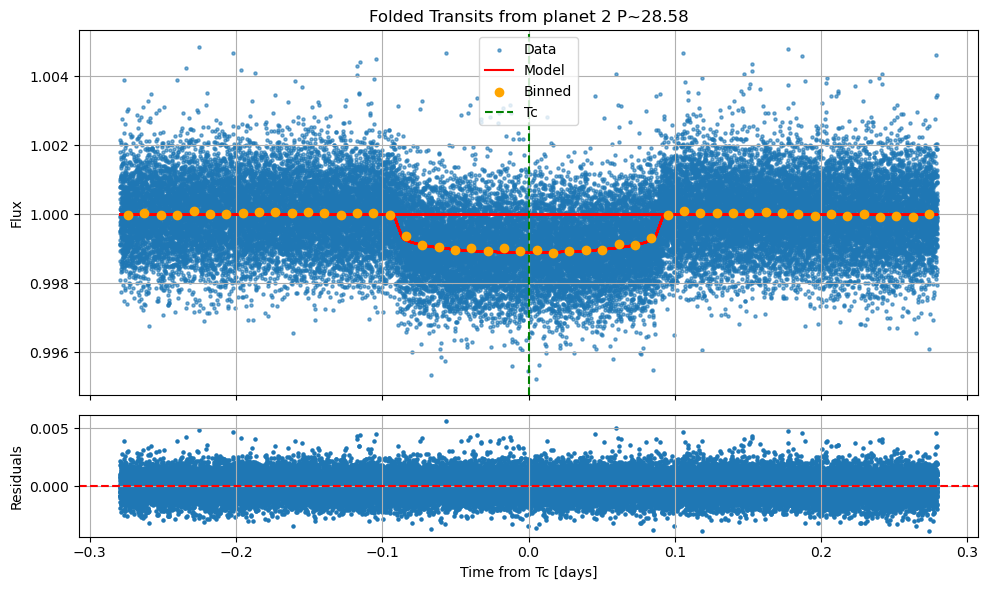

In [698]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 2 P~{round(planet_2_period.value, 3)}')

## Planet 3

In [699]:
### Planet params (from barros et al 2022)
# planet b
per_3=  38.352562 #38.353037
rp_3=  0.0305954481349672 #0.02916
b_3=  0.323085496752003 #0.440
T14_3= 5.51199861214238 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [700]:
tc_guess_3 = transit_times_3
### get tc ranges for fit
tc_3 = []
for i in range(len(tc_guess_3)):
    start = tc_guess_3[i] - ttv_hour
    end = tc_guess_3[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_3.append(t)

In [701]:
### initialize arrays
tc_chi = np.zeros(len(tc_3))
tc_chi_parabola = np.zeros(len(tc_3))
ttv = np.zeros(len(tc_3))
ttv_p = np.zeros(len(tc_3))
errors = []
errors_p = []
err_tc_chi = []

In [702]:
tc_chi_3, ttv_3, tc_err3 = plot_chi_sq(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)

In [703]:
print(tc_chi_3)

[2433.91657462 2625.67249164 2664.02531399 2702.35279639 2740.71821503
 2817.41084374 2932.46231394 3354.30350893 3392.65950889 3546.07284782
 3584.40971432 3622.77032492 3661.12761465]


In [704]:
### after inspection of single transits
values_to_remove_3 = [2625.8268773960335, 3584.491360619078]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_3 = [x for x in tc_chi_3 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_3)]

# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_3_cleaned = []
ttv_3_cleaned = []
tc_err_3_cleaned = []

for i in range(len(tc_chi_3)):
    if not any(math.isclose(tc_chi_3[i], val, abs_tol=tolerance) for val in values_to_remove_3):
        tc_chi_3_cleaned.append(tc_chi_3[i])
        ttv_3_cleaned.append(ttv_3[i])
        tc_err_3_cleaned.append(tc_err3[i])

# Overwrite the originals if needed
tc_chi_3 = tc_chi_3_cleaned
ttv_3 = ttv_3_cleaned
tc_err3 = tc_err_3_cleaned


print("Modified List (after removal):", tc_chi_3)


Modified List (after removal): [2433.9165746177628, 2664.0253139879796, 2702.3527963863708, 2740.71821502839, 2817.4108437379555, 2932.462313935031, 3354.303508928905, 3392.6595088877752, 3546.0728478211595, 3622.7703249199426, 3661.1276146501823]


In [705]:
# tc_err_3 = []
# for i in range(len(tc_err3)):
#     sig = np.sqrt(tc_err3[i][0]**2 + tc_err3[i][1]**2)
#     tc_err_3.append(sig)

tc_err_3 = []
for i in range(len(tc_err3)):
    if len(tc_err3[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err3[i][0]**2 + tc_err3[i][1]**2)
        tc_err_3.append(sig)
    else:
        print(f"Unexpected format in tc_err3[{i}]: {tc_err3[i]}, {tc_chi_3[i]}")

print(tc_err_3)

[0.0019124458985092074, 0.0020098763399376807, 0.0023376556757796637, 0.0013761296886865859, 0.0021661847383240775, 0.0011970045789523502, 0.001804975015179802, 0.00175962527770549, 0.0015111862068187452, 0.001621428959883142, 0.001699098007493539]


In [706]:
# Transit windows
buffer = 1.5 * T14_3
transit_times_3 = tc_chi_3

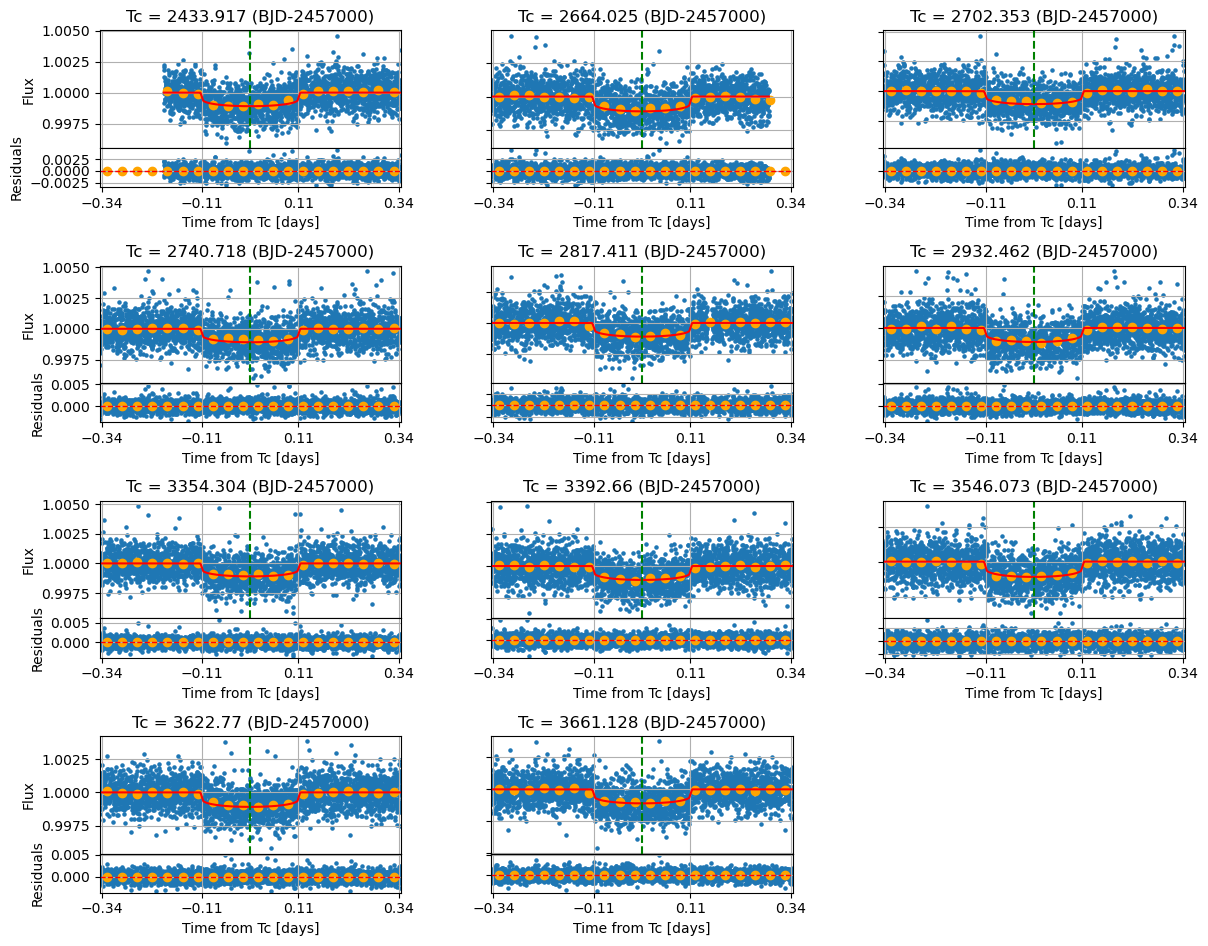

In [707]:
plot_transits(transit_times_3, per_3, rp_3, b_3, T14_3, u1, u2)

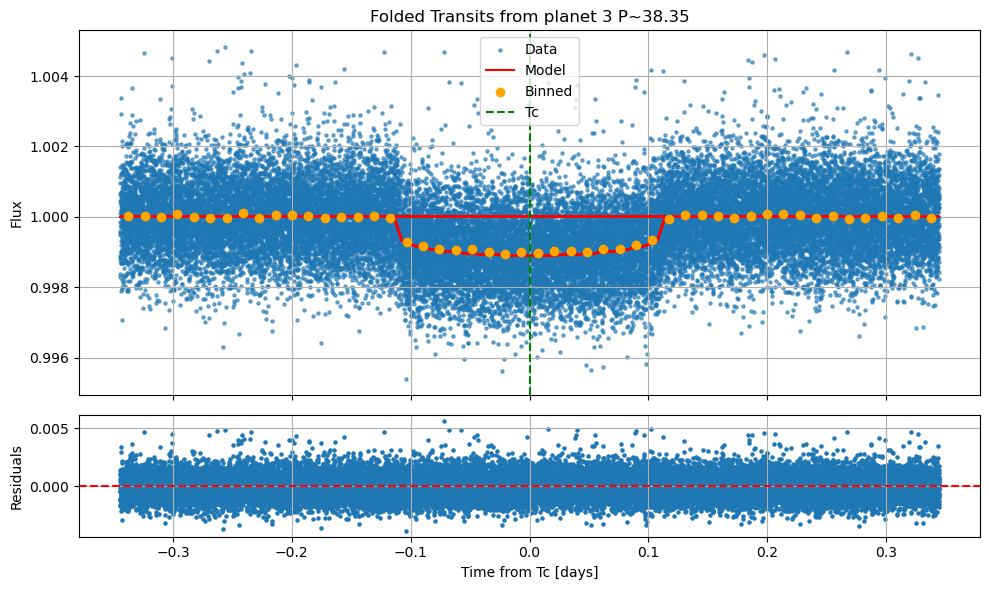

In [708]:
plot_folded_from_transits(transit_times_3, time, flux, per_3, rp_3, b_3, T14_3, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 3 P~{round(planet_3_period.value, 3)}')

## Save data

In [709]:
print(len(transit_times_2))
print(len(transit_times_3))

16
11


In [710]:
print(planet_1_period.value)
print(planet_2_period.value)
print(planet_3_period.value)
print(planet_1_t0.value)
print(planet_2_t0.value)
print(planet_3_t0.value)
print(transit_times_2)
print(transit_times_3)
print(tc_err_1)
print(tc_err_2)
print(tc_err_3)
transit_times_2 = np.array(transit_times_2)
transit_times_3 = np.array(transit_times_3)

# Calculate the indices of transits for each planet
indices_1 = np.round((transit_times_1 - planet_1_t0.value) / planet_1_period.value).astype(int)
indices_2 = np.round((transit_times_2 - planet_2_t0.value) / planet_2_period.value).astype(int)
indices_3 = np.round((transit_times_3 - planet_3_t0.value) / planet_3_period.value).astype(int)

print("Indices of transits for planet 1:", indices_1)
print("Indices of transits for planet 2:", indices_2)
print("Indices of transits for planet 3:", indices_3)


8.880088008800879
28.579657965796578
38.35013501350135
2425.79945919191
2440.56945919191
2433.90945919191
[2440.5453772579517, 2612.0257498217884, 2640.607360037848, 2697.772009576271, 2726.3527350293425, 2812.097640098747, 2840.6726872691265, 2926.4182639328533, 3297.970203178181, 3355.1306343302267, 3383.7110057186396, 3440.8761217520487, 3555.194805258147, 3583.7676407579665, 3612.3498560606936, 3640.9332567617016]
[2433.9165746177628, 2664.0253139879796, 2702.3527963863708, 2740.71821502839, 2817.4108437379555, 2932.462313935031, 3354.303508928905, 3392.6595088877752, 3546.0728478211595, 3622.7703249199426, 3661.1276146501823]
[0.0013705661720473886, 0.0012296942320404376, 0.0011142675737992617, 0.001462551185819019, 0.0014869999108567684, 0.0009940910857648274, 0.0012872364586039328, 0.0011431324673233953, 0.0016129513865078184, 0.0012999559480740637, 0.001173479682737986, 0.0011902832984297183, 0.0013558738801163603, 0.0010824123887137628, 0.0009490598586804424, 0.001229098371886

In [711]:
### saving data for planets 2 and 3 (resonant pair)

planet_number = []
# for i in range(len(transit_times_1)):
#     planet_number.append(1)
for i in range(len(transit_times_2)):
    planet_number.append(2)
for i in range(len(transit_times_3)):
    planet_number.append(3)

all_transit_num = [] 
# for i in range(len(indices_1)):
#     all_transit_num.append(indices_1[i])
for i in range(len(indices_2)):
    all_transit_num.append(indices_2[i])
for i in range(len(indices_3)):
    all_transit_num.append(indices_3[i])

all_obs_tc = []
# for i in range(len(transit_times_1)):
#     all_obs_tc.append(transit_times_1[i])
for i in range(len(transit_times_2)):
    all_obs_tc.append(transit_times_2[i])
for i in range(len(transit_times_3)):
    all_obs_tc.append(transit_times_3[i])

all_obs_tc_err = []
# for i in range(len(tc_err_1)):
#     all_obs_tc_err.append(tc_err_1[i])
for i in range(len(tc_err_2)):
    all_obs_tc_err.append(tc_err_2[i])
for i in range(len(tc_err_3)):
    all_obs_tc_err.append(tc_err_3[i])



In [712]:
output_file = "toi_1339_transit_data_20s.txt"
### save
data_to_save = np.column_stack((planet_number, all_transit_num, all_obs_tc, all_obs_tc_err))

### Define header
header = "Planet_num Index Tc Tc_err"

### Save to file
np.savetxt(output_file, data_to_save, fmt='%d %d %.8f %.8f', header=header, comments='')

print(f"Results saved to {output_file}")

Results saved to toi_1339_transit_data_20s.txt


# O-C

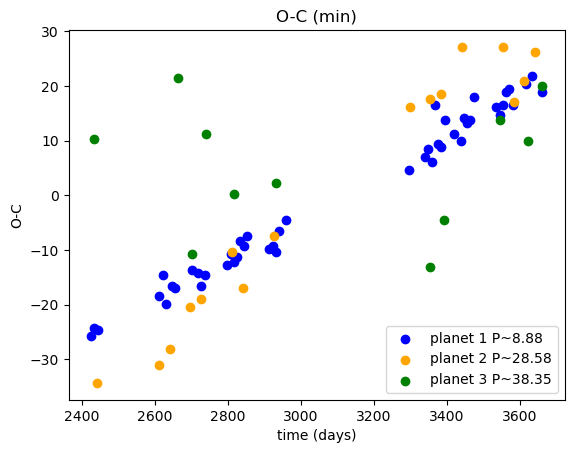

In [713]:
# TTV
ttv_1 = np.array(ttv_1)
ttv_2 = np.array(ttv_2)
ttv_3 = np.array(ttv_3)


plt.scatter(tc_chi_1, ttv_1*(24*60),c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

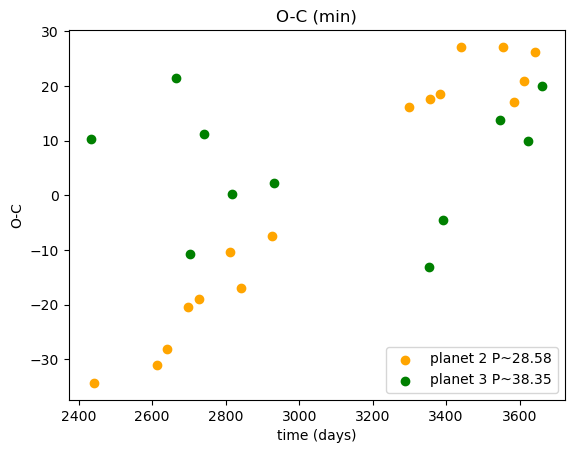

In [714]:
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

[ 2.66271293e-03  6.85593897e-02 -1.55431278e+01 -9.90958634e-04]
[ 5.82413305e-03  6.32972217e-02  3.31901420e+00 -1.23320124e-03]


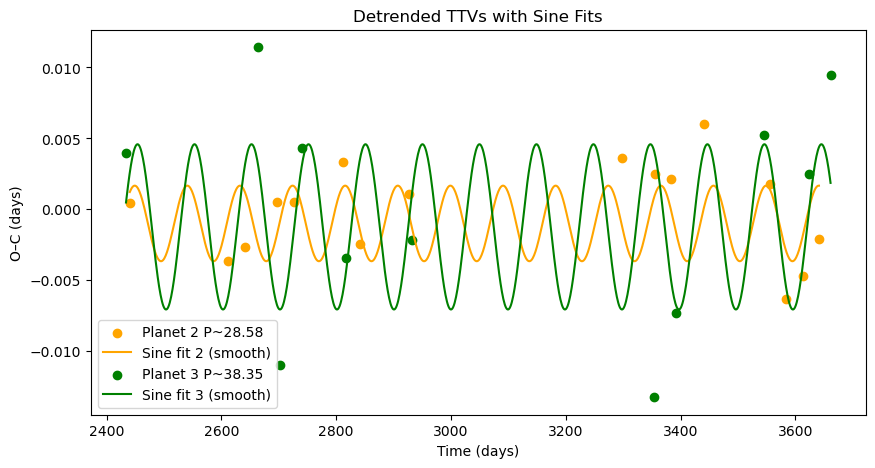

In [715]:
# Fit functions
def linear(x, a, b):
    return a * x + b

def sine(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset
# Fit and subtract for planet 2
popt_lin_2, _ = curve_fit(linear, tc_chi_2, ttv_2)
ttv_2_detrended = ttv_2 - linear(np.array(tc_chi_2), *popt_lin_2)

# Fit and subtract for planet 3
popt_lin_3, _ = curve_fit(linear, tc_chi_3, ttv_3)
ttv_3_detrended = ttv_3 - linear(np.array(tc_chi_3), *popt_lin_3)

# Initial guess: amplitude, frequency (rad/day), phase, offset
guess_2 = [0.01, 2 * np.pi / 100, 0, 0]
popt_sin_2, _ = curve_fit(sine, tc_chi_2, ttv_2_detrended, p0=guess_2)
print(popt_sin_2)

guess_3 = [0.03, 2 * np.pi / 100, 0, 0]
popt_sin_3, _ = curve_fit(sine, tc_chi_3, ttv_3_detrended, p0=guess_3)
print(popt_sin_3)

# Dense time arrays for smooth plots
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Detrended fits: only plot sine on linear-subtracted times
sine_fit_2 = sine(dense_time_2, *popt_sin_2)
sine_fit_3 = sine(dense_time_3, *popt_sin_3)

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended, color='orange', label=f'Planet 2 P~{round(planet_2_period.value, 3)}')
plt.plot(dense_time_2, sine_fit_2, 'orange', label='Sine fit 2 (smooth)')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended, color='green', label=f'Planet 3 P~{round(planet_3_period.value, 3)}')
plt.plot(dense_time_3, sine_fit_3, 'g', label='Sine fit 3 (smooth)')

plt.title('Detrended TTVs with Sine Fits')
plt.xlabel('Time (days)')
plt.ylabel('O–C (days)')
plt.legend()
plt.show()

[ 3.78441761e-05 -1.17345761e-01 -3.17404710e-03  1.16759559e-02
  1.55530773e+01]
[ 1.23780199e-06 -9.77453417e-04 -5.17592694e-03  1.48760190e-02
  1.42789671e+00]


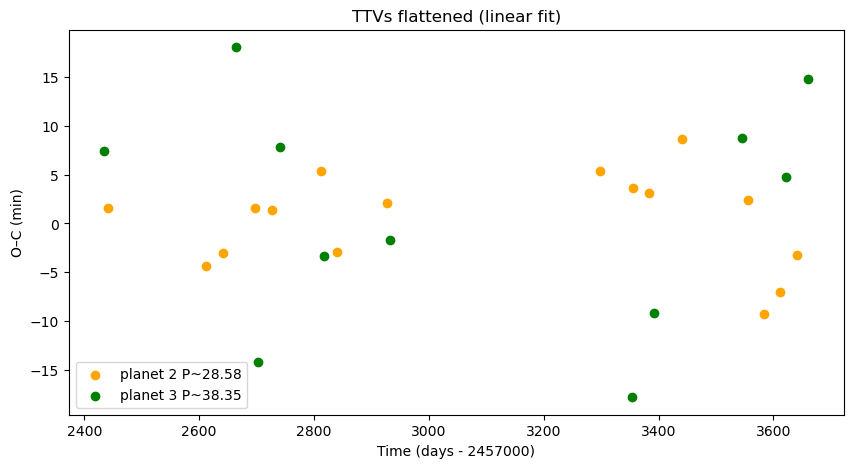

In [716]:
def linear_sine(t, a, b, A, omega, phase):
    return a * t + b + A * np.sin(omega * t + phase)

# Convert TTVs to minutes
ttv_2_min = np.array(ttv_2)
ttv_3_min = np.array(ttv_3) 

# Initial guesses: [slope, intercept, amplitude, omega, phase]
guess_2 = [28, 0, 0.01, 0.5*3.26255812e-02, 0]
guess_3 = [38, 0, 0.05, 0.5*3.05795071e-02, 0]

# Fit for planet 2
popt_2, _ = curve_fit(linear_sine, tc_chi_2, ttv_2_min, p0=guess_2)

# Fit for planet 3
popt_3, _ = curve_fit(linear_sine, tc_chi_3, ttv_3_min, p0=guess_3)

print(popt_2)
print(popt_3)

def linear_only(t, a, b):
    return a * t + b

ttv_2_detrended = ttv_2_min - linear_only(np.array(tc_chi_2), *popt_2[:2])
ttv_3_detrended = ttv_3_min - linear_only(np.array(tc_chi_3), *popt_3[:2])

# Dense time arrays for smooth curves
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Full model predictions
fit_2_full = linear_sine(dense_time_2, *popt_2)
fit_3_full = linear_sine(dense_time_3, *popt_3)

# Sine-only on detrended
fit_2_sine = fit_2_full - linear_only(dense_time_2, *popt_2[:2])
fit_3_sine = fit_3_full - linear_only(dense_time_3, *popt_3[:2])

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended*24*60, color='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
# plt.plot(dense_time_2, fit_2_sine, 'orange', label='Sine fit 2')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended*24*60, color='green', label=f'planet 3 P~{round(planet_3_period.value,3)}')
# plt.plot(dense_time_3, fit_3_sine, 'g', label='Sine fit 3')

plt.title('TTVs flattened (linear fit)')
plt.xlabel(f'Time (days - {TESS_offset})')
plt.ylabel('O–C (min)')
plt.legend()
plt.show()

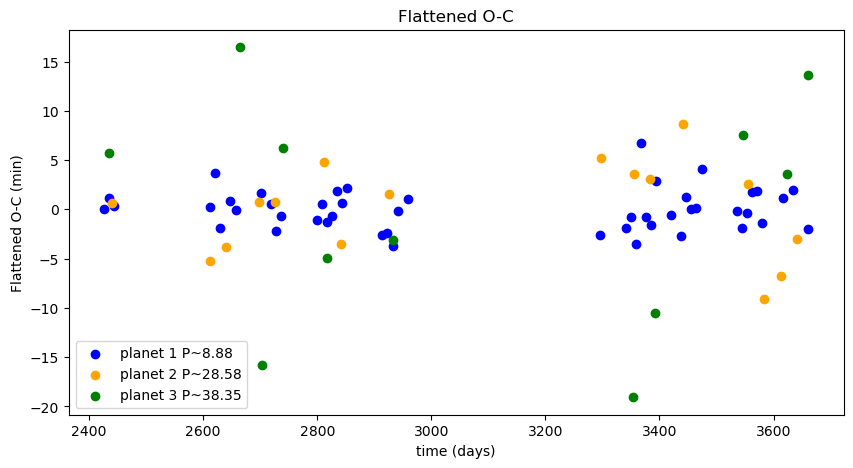

In [717]:
# Fit a linear function to the TTV data
coeffs_1 = np.polyfit(tc_chi_1, ttv_1*(24*60), 1)
linear_fit_1 = np.polyval(coeffs_1, tc_chi_1)

coeffs_2 = np.polyfit(tc_chi_2, ttv_2*(24*60), 1)
linear_fit_2 = np.polyval(coeffs_2, tc_chi_2)

coeffs_3 = np.polyfit(tc_chi_3, ttv_3*(24*60), 1)
linear_fit_3 = np.polyval(coeffs_3, tc_chi_3)

# Subtract the linear fit from the TTV data
ttv_1_detrended = ttv_1*(24*60) - linear_fit_1
ttv_2_detrended = ttv_2*(24*60) - linear_fit_2
ttv_3_detrended = ttv_3*(24*60) - linear_fit_3


plt.figure(figsize=(10, 5))
# Plot the detrended data
plt.scatter(tc_chi_1, ttv_1_detrended,c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2_detrended,c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3_detrended,c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.legend()
plt.show()

## Multi-harmonic fit

In [718]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [719]:
j = 4 # 4:3 MMR
p_2 = planet_2_period.value
p_3 = planet_3_period.value
tc_2 = planet_2_t0.value
tc_3 = planet_3_t0.value


delta = delta_(p_2, p_3, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_3, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.006401171579743181
TTV period: 1497.7779667265215 days


In [720]:
def ttv_amp_1(P1, m2, m_star, j, delta, f, Z):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z)/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z)/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

In [721]:
### assuming circular orbit
Z=0


In [722]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])


In [723]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [724]:
from scipy.optimize import least_squares
indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)
indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)

### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 2.44055123e+03  2.85804115e+01  6.86119034e-03  2.43389896e+03
  3.83510713e+01 -1.71005958e-02  1.72502317e+03  2.89787640e+03]


In [725]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, A_bc_err, t_c0_err, P_c_err, A_cb_err, P_cb_err, t_cb0_err = param_errors

In [726]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 2440.55123470 ± 0.00470334
   P_b = 28.58041147 ± 0.00029376
  A_bc = 0.00686119 ± 0.00452650
  t_c0 = 2433.89896199 ± 0.01119804
   P_c = 38.35107130 ± 0.00093467
  A_cb = -0.01710060 ± 0.01058082
  P_cb = 1725.02317110 ± 549.40420261
 t_cb0 = 2897.87639995 ± 18.72181533


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_2665/2680994792.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


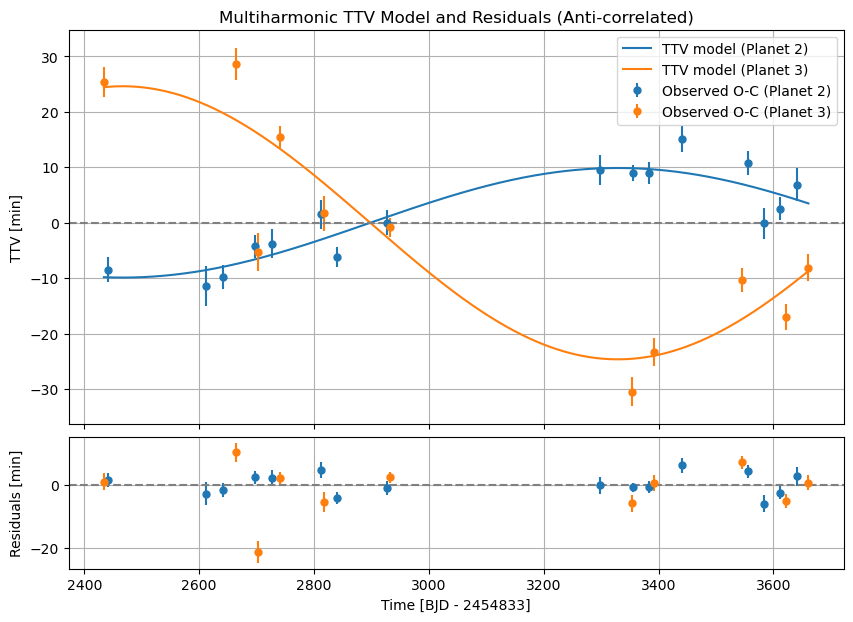

In [727]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# Combine observed times to set the time range
all_times = np.concatenate([transit_times_2, transit_times_3])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) * 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) * 1440  # <- NEGATE here

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)

# Observed O-C residuals in minutes
oc_b = (np.array(transit_times_2) - t_lin_obs_b) * 1440
oc_c = (np.array(transit_times_3) - t_lin_obs_c) * 1440


# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) * 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) * 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet 2)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet 3)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(tc_err_2)*1440, fmt='o',
             color='tab:blue', label='Observed O-C (Planet 2)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(tc_err_3)*1440, fmt='o',
             color='tab:orange', label='Observed O-C (Planet 3)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [min]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(tc_err_2)*1440, fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(tc_err_3)*1440, fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [min]")
ax2.grid(True)

plt.tight_layout()
plt.show()


In [728]:
print('Predicted values from Lubin et al 2022:')
print('predicted P_23: 1490 ± 10 days')
print('predicted A_23: 15.5 ± 9.1 min')
print('predicted A_32: 59.2 ± 13.8 min')
print('Multi-harmonic fit values:')
print(f'P_23: {np.round(P_cb,6)} ± {np.round(P_cb_err,6)} days')
print(f'A_23: {np.round(A_bc,6)*1440} ± {np.round(A_bc_err,6)*1440} min')
print(f'A_32: {np.round(A_cb,6)*1440} ± {np.round(A_cb_err,6)*1440} min')

Predicted values from Lubin et al 2022:
predicted P_23: 1490 ± 10 days
predicted A_23: 15.5 ± 9.1 min
predicted A_32: 59.2 ± 13.8 min
Multi-harmonic fit values:
P_23: 1725.023171 ± 549.404203 days
A_23: 9.87984 ± 6.51744 min
A_32: -24.62544 ± 15.23664 min
